In [10]:
"""
Назначение файла: базовый EDA для Bitcoin Elliptic-like датасета.
Основные шаги: загрузка итоговых таблиц, анализ time_step, признаков, классов и визуализация подграфа.
Зависимости или источники данных: data/processed/*.csv, data/interim/*.parquet.
"""

'\nНазначение файла: базовый EDA для Bitcoin Elliptic-like датасета.\nОсновные шаги: загрузка итоговых таблиц, анализ time_step, признаков, классов и визуализация подграфа.\nЗависимости или источники данных: data/processed/*.csv, data/interim/*.parquet.\n'

# Basic EDA dynamic graph

Ноутбук предназначен для быстрой проверки структуры данных после запуска `scripts/build_dataset.py`. Визуализация графа строится только на части ребер, чтобы не перегружать рендеринг.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

features_path = PROCESSED_DIR / "parsed_txs_features_named.csv"
edges_path = PROCESSED_DIR / "parsed_txs_edgelist.csv"
classes_path = PROCESSED_DIR / "parsed_txs_classes.csv"
scores_path = PROCESSED_DIR / "parsed_txs_scores_template.csv"

features = pd.read_csv(features_path) if features_path.exists() else pd.DataFrame()
edges = pd.read_csv(edges_path) if edges_path.exists() else pd.DataFrame()
classes = pd.read_csv(classes_path) if classes_path.exists() else pd.DataFrame()
scores = pd.read_csv(scores_path) if scores_path.exists() else pd.DataFrame()

print(f"features {features.shape}")
print(f"edges {edges.shape}")
print(f"classes {classes.shape}")
print(f"scores {scores.shape}")

features (226080, 29)
edges (343895, 2)
classes (226080, 2)
scores (226080, 3)


In [12]:
display(features.head())
display(edges.head())
display(classes.head())

,tx_hash,time_step,block_height,timestamp,input_count,output_count,total_input_value,total_output_value,fee,fee_rate,...,weak_component_size,num_unique_input_addresses,num_unique_output_addresses,has_many_inputs,has_many_outputs,has_high_fee,has_small_outputs,avg_neighbor_fee,avg_neighbor_total_output_value,sum_neighbor_total_output_value
0,0002d9641b375f36f3904701612c167b443b715d01795b...,1,948624,1778338146,1,2,0.000271,0.000258,0.000013,3.101695e-08,...,2,1.0,2.0,0,0,0,1,0.0,0.0,0.0
1,0029719cce0d260a967a2b02b8ebbc6cffeca193bd22b1...,1,948624,1778338146,1,1,0.000015,0.000005,0.000010,2.594595e-08,...,2,1.0,1.0,0,0,0,1,0.0,0.0,0.0
2,002af9f29d7f3c994db80974ff44085105ff21989bcbd7...,1,948624,1778338146,1,2,0.001677,0.001662,0.000015,6.918919e-08,...,91980,1.0,2.0,0,0,0,0,0.0,0.0,0.0
3,002ec10f7a9adb2f0884142868b51ce0edac337b4110a5...,1,948624,1778338146,1,1,0.001524,0.001516,0.000009,4.583333e-08,...,5,1.0,1.0,0,0,0,0,0.0,0.0,0.0
4,003352274dc20dae502f0ae0802d60351e4c1f27e28f08...,1,948624,1778338146,1,2,0.000209,0.000197,0.000012,5.230769e-08,...,3,1.0,2.0,0,0,0,1,0.0,0.0,0.0


,txId1,txId2
0,5153545842380508,b7989325180c065d1ea8ad0b47cec383c57453202cdfbe...
1,285678123987082,50a252cac8225b6737f4ad21898ad8362e334f136fefa5...
2,4456681761631389,fb6cb780c7c4c15524037223d7a7d91c25f45d224bf95d...
3,8033193008786163,fb6cb780c7c4c15524037223d7a7d91c25f45d224bf95d...
4,6727576261893025,fb6cb780c7c4c15524037223d7a7d91c25f45d224bf95d...


,txId,class
0,0002d9641b375f36f3904701612c167b443b715d01795b...,unknown
1,0029719cce0d260a967a2b02b8ebbc6cffeca193bd22b1...,unknown
2,002af9f29d7f3c994db80974ff44085105ff21989bcbd7...,unknown
3,002ec10f7a9adb2f0884142868b51ce0edac337b4110a5...,unknown
4,003352274dc20dae502f0ae0802d60351e4c1f27e28f08...,unknown


## Динамика по time_step

,tx_count,mean_fee,median_fee,total_output_value
time_step,,,,
1,39074,0.000014,0.000010,19247.780431
2,35743,0.000015,0.000011,29104.138125
3,23960,0.000016,0.000011,15302.262230
4,33728,0.000016,0.000012,20783.070233
5,51220,0.000012,0.000009,29493.177903
6,26497,0.000011,0.000008,15437.799224
7,15858,0.000013,0.000006,24499.539209


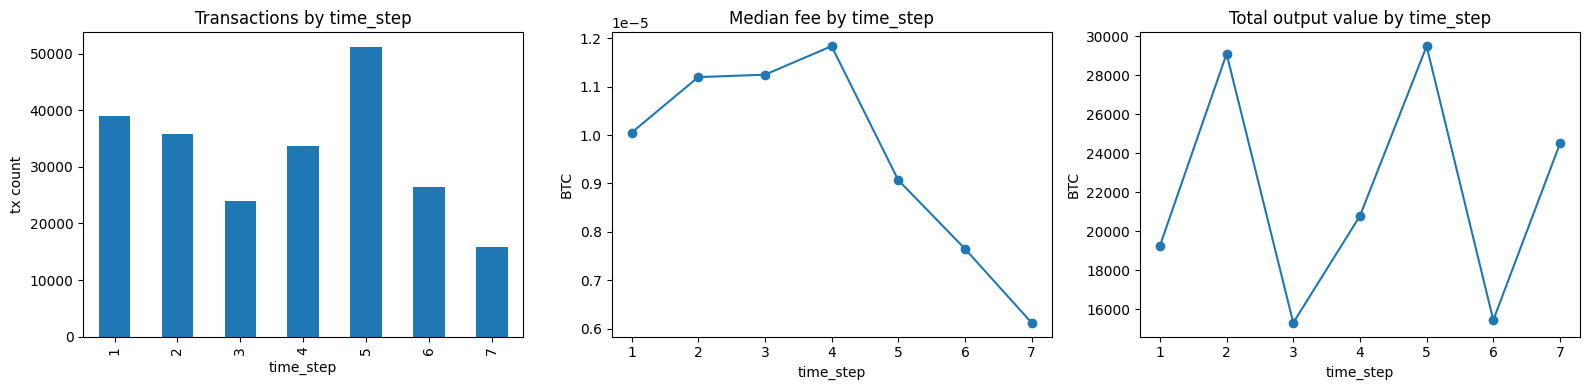

In [13]:
if features.empty:
    print("features пустой")
else:
    step_stats = features.groupby("time_step").agg(
        tx_count=("tx_hash", "count"),
        mean_fee=("fee", "mean"),
        median_fee=("fee", "median"),
        total_output_value=("total_output_value", "sum"),
    )
    display(step_stats.head(20))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    step_stats["tx_count"].plot(kind="bar", ax=axes[0])
    axes[0].set_title("Transactions by time_step")
    axes[0].set_xlabel("time_step")
    axes[0].set_ylabel("tx count")

    step_stats["median_fee"].plot(kind="line", marker="o", ax=axes[1])
    axes[1].set_title("Median fee by time_step")
    axes[1].set_xlabel("time_step")
    axes[1].set_ylabel("BTC")

    step_stats["total_output_value"].plot(kind="line", marker="o", ax=axes[2])
    axes[2].set_title("Total output value by time_step")
    axes[2].set_xlabel("time_step")
    axes[2].set_ylabel("BTC")
    plt.tight_layout()

## Распределения признаков

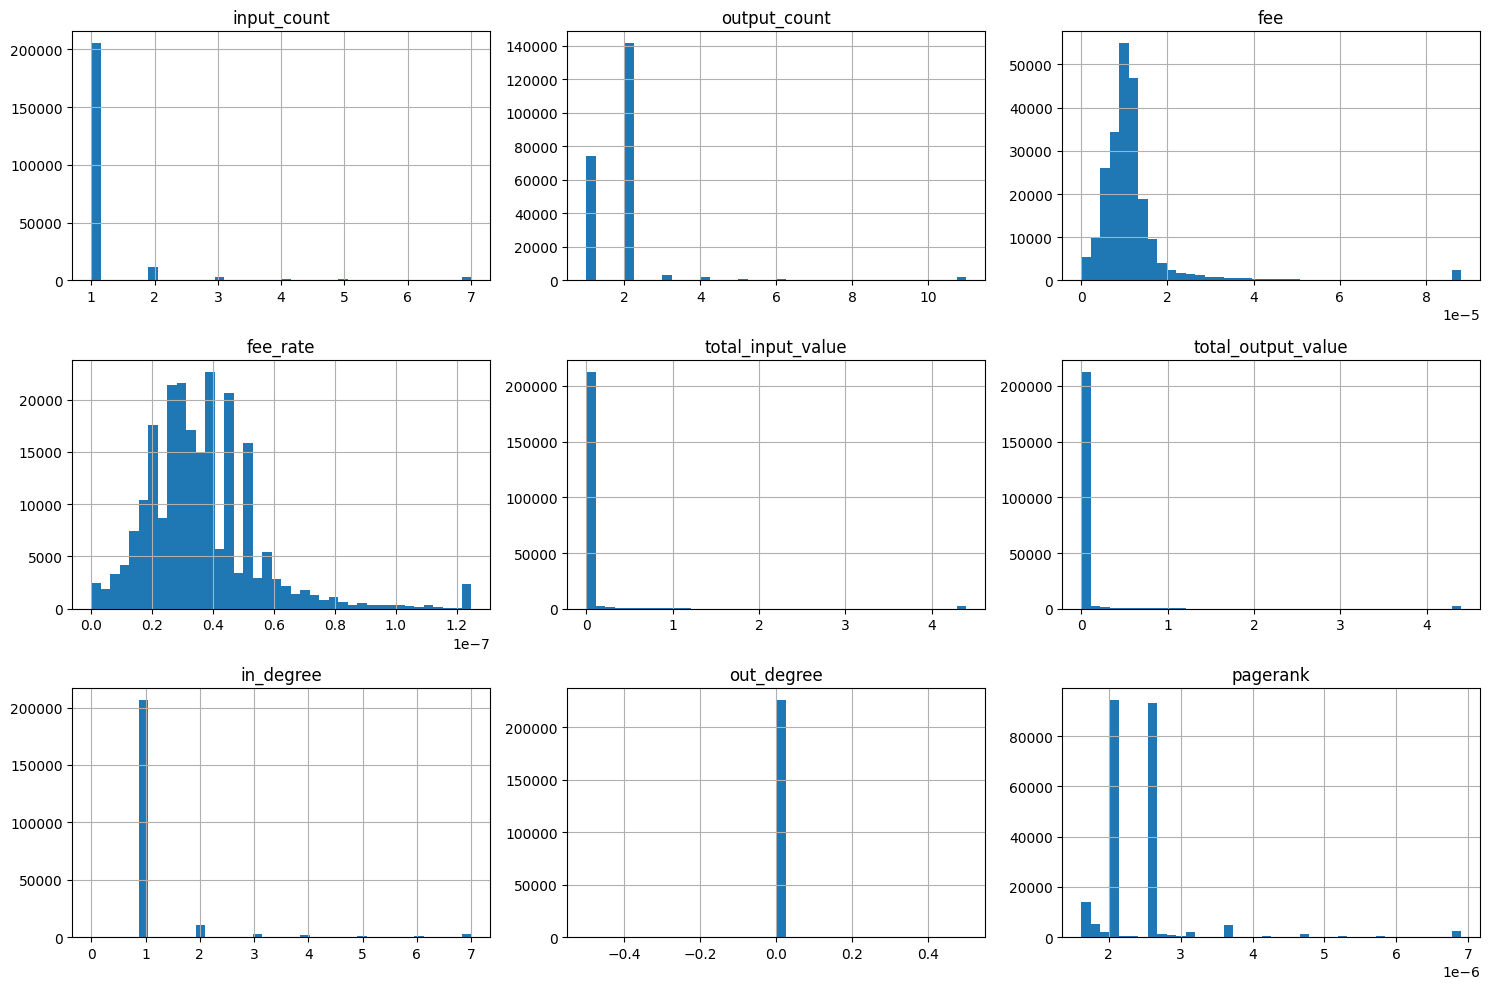

In [14]:
if features.empty:
    print("features пустой")
else:
    numeric_columns = [
        "input_count",
        "output_count",
        "fee",
        "fee_rate",
        "total_input_value",
        "total_output_value",
        "in_degree",
        "out_degree",
        "pagerank",
    ]
    available_columns = [column for column in numeric_columns if column in features]
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    for ax, column in zip(axes.ravel(), available_columns):
        series = features[column].fillna(0)
        upper = series.quantile(0.99) if series.nunique() > 1 else series.max()
        series.clip(upper=upper).hist(bins=40, ax=ax)
        ax.set_title(column)
    for ax in axes.ravel()[len(available_columns):]:
        ax.axis("off")
    plt.tight_layout()

## Флаги и классы

,count
class,
unknown,226080


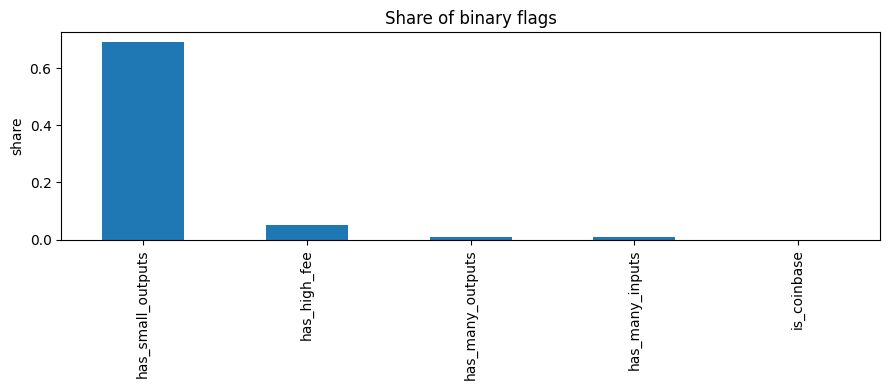

In [15]:
if features.empty:
    print("features пустой")
else:
    flag_columns = [
        "is_coinbase",
        "has_many_inputs",
        "has_many_outputs",
        "has_high_fee",
        "has_small_outputs",
    ]
    flag_share = features[flag_columns].mean().sort_values(ascending=False)
    flag_share.plot(kind="bar", figsize=(9, 4), title="Share of binary flags")
    plt.ylabel("share")
    plt.tight_layout()

if not classes.empty:
    display(classes["class"].value_counts(dropna=False).to_frame("count"))

## Визуализация подграфа

Рисуется только небольшой подграф. Вес ребра в подписи берется как `total_output_value` целевой транзакции, если она есть в таблице признаков.

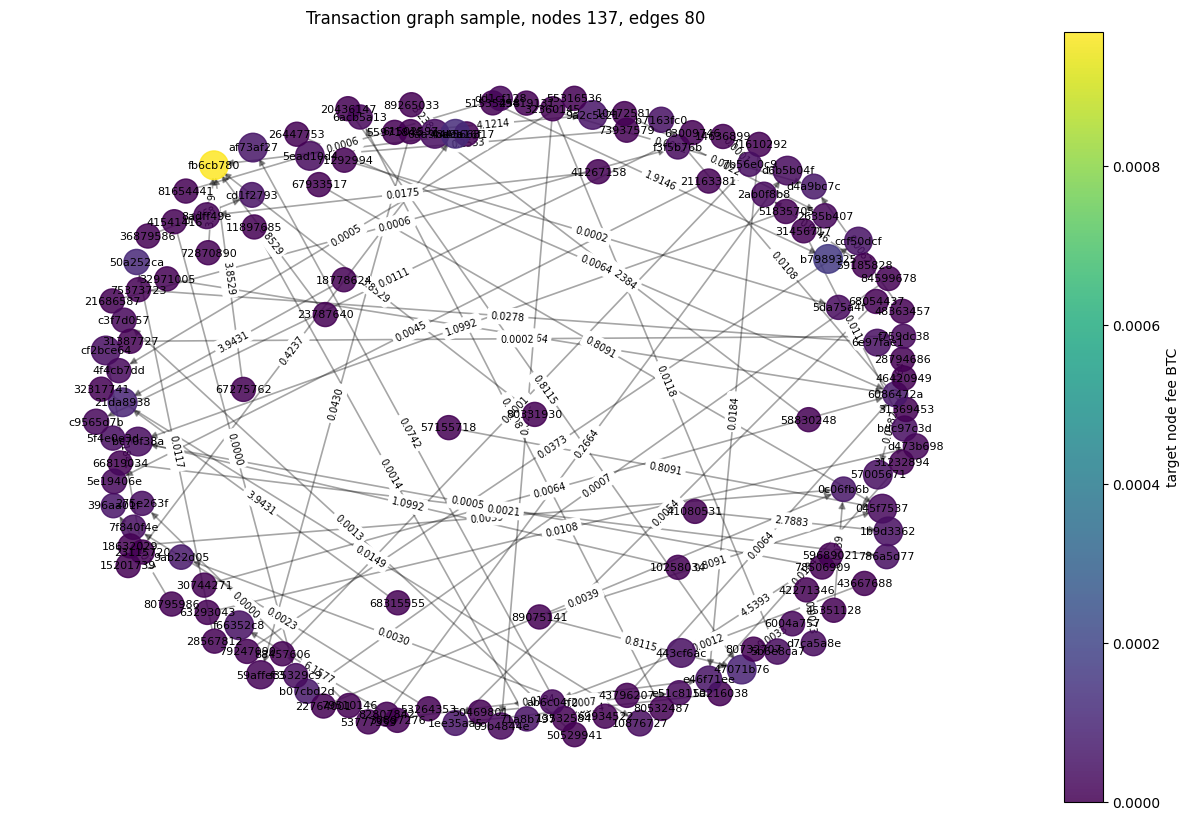

In [16]:
MAX_EDGES = 80
SELECT_TIME_STEP = None

if edges.empty:
    print("Edge list пустой")
    print("Пересоберите датасет: python scripts\\build_dataset.py --time-window-hours 1")
else:
    edge_sample = edges.copy()
    if SELECT_TIME_STEP is not None and not features.empty:
        step_nodes = set(
            features.loc[features["time_step"] == SELECT_TIME_STEP, "tx_hash"].astype(str)
        )
        edge_sample = edge_sample[
            edge_sample["txId1"].astype(str).isin(step_nodes)
            | edge_sample["txId2"].astype(str).isin(step_nodes)
        ]
    edge_sample = edge_sample.head(MAX_EDGES).copy()

    graph = nx.from_pandas_edgelist(
        edge_sample,
        source="txId1",
        target="txId2",
        create_using=nx.DiGraph(),
    )
    value_map = {}
    fee_map = {}
    if not features.empty:
        value_map = features.set_index("tx_hash")["total_output_value"].to_dict()
        fee_map = features.set_index("tx_hash")["fee"].to_dict()

    edge_labels = {}
    for source, target in graph.edges():
        weight = float(value_map.get(target, 0.0))
        graph[source][target]["weight"] = weight
        edge_labels[(source, target)] = f"{weight:.4f}"

    node_sizes = [300 + 2500 * min(float(value_map.get(node, 0.0)), 0.05) for node in graph.nodes()]
    node_colors = [float(fee_map.get(node, 0.0)) for node in graph.nodes()]
    labels = {node: str(node)[:8] for node in graph.nodes()}

    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(graph, seed=42, k=0.9)
    nodes = nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap="viridis",
        alpha=0.85,
    )
    nx.draw_networkx_edges(graph, pos, arrows=True, alpha=0.35, width=1.2)
    nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)
    plt.colorbar(nodes, label="target node fee BTC")
    plt.title(f"Transaction graph sample, nodes {graph.number_of_nodes()}, edges {graph.number_of_edges()}")
    plt.axis("off")
    plt.show()

## Структура подграфа

In [17]:
if edges.empty:
    print("Нет ребер для анализа")
else:
    graph = nx.from_pandas_edgelist(
        edges.head(500),
        source="txId1",
        target="txId2",
        create_using=nx.DiGraph(),
    )
    weak_components = list(nx.weakly_connected_components(graph))
    degree_values = [degree for _, degree in graph.degree()]
    print(f"sample nodes {graph.number_of_nodes()}")
    print(f"sample edges {graph.number_of_edges()}")
    print(f"weak components {len(weak_components)}")
    print(f"max weak component size {max(map(len, weak_components)) if weak_components else 0}")
    pd.Series(degree_values).describe().to_frame("degree")

sample nodes 818
sample edges 500
weak components 318
max weak component size 31


## Промежуточные таблицы

In [18]:
for table_name in ["blocks", "transactions", "inputs", "outputs"]:
    path = INTERIM_DIR / f"{table_name}.parquet"
    if not path.exists():
        print(f"{table_name} not found")
        continue
    table = pd.read_parquet(path)
    print(f"{table_name} {table.shape}")
    display(table.head())

blocks (50, 7)


,block_hash,height,timestamp,datetime_utc,prev_block,n_tx,size
0,00000000000000000000daaafa1adfbf622ce229fae3f7...,948624,1778338146,2026-05-09T14:49:06+00:00,0000000000000000000138d3ff3fbceb396212ccd504af...,5292,1827810
1,000000000000000000005846c42438750704d2221f5476...,948625,1778338300,2026-05-09T14:51:40+00:00,00000000000000000000daaafa1adfbf622ce229fae3f7...,4652,1800788
2,000000000000000000004f49dd80801dedd0de2d48780a...,948626,1778338691,2026-05-09T14:58:11+00:00,000000000000000000005846c42438750704d2221f5476...,5233,1889173
3,0000000000000000000085e3f148bbde0adad0bff3eb07...,948627,1778338763,2026-05-09T14:59:23+00:00,000000000000000000004f49dd80801dedd0de2d48780a...,5040,1833365
4,00000000000000000001fb8a2549131cf7778583e931f7...,948628,1778338836,2026-05-09T15:00:36+00:00,0000000000000000000085e3f148bbde0adad0bff3eb07...,4512,1853507


transactions (226080, 15)


,tx_hash,tx_index,block_hash,block_height,timestamp,datetime_utc,size,vin_sz,vout_sz,input_count,output_count,total_input_value,total_output_value,fee,is_coinbase
0,1b92bc5c635ca4f66da476f8bafe8c2e3d1a1a2cf60840...,8747762466476009,00000000000000000000daaafa1adfbf622ce229fae3f7...,948624,1778338146,2026-05-09T14:49:06+00:00,378,1,4,1,4,0.000000,3.202430,0.000000,False
1,b7989325180c065d1ea8ad0b47cec383c57453202cdfbe...,5975616262929103,00000000000000000000daaafa1adfbf622ce229fae3f7...,948624,1778338146,2026-05-09T14:49:06+00:00,223,1,2,1,2,1.914776,1.914612,0.000164,False
2,50a252cac8225b6737f4ad21898ad8362e334f136fefa5...,8907514194256608,00000000000000000000daaafa1adfbf622ce229fae3f7...,948624,1778338146,2026-05-09T14:49:06+00:00,223,1,2,1,2,0.011778,0.011669,0.000109,False
3,fb6cb780c7c4c15524037223d7a7d91c25f45d224bf95d...,6498357577656841,00000000000000000000daaafa1adfbf622ce229fae3f7...,948624,1778338146,2026-05-09T14:49:06+00:00,1955,5,12,5,12,3.853883,3.852914,0.000969,False
4,9ab22d05d3445380d55a518995b860da6aca518ed53e68...,2156025470213957,00000000000000000000daaafa1adfbf622ce229fae3f7...,948624,1778338146,2026-05-09T14:49:06+00:00,191,1,1,1,1,0.003112,0.003048,0.000064,False


inputs (358895, 7)


,tx_hash,block_height,input_index,prev_tx_hash,prev_output_index,input_value,input_address
0,1b92bc5c635ca4f66da476f8bafe8c2e3d1a1a2cf60840...,948624,0,None,4294967295,0.000000,None
1,b7989325180c065d1ea8ad0b47cec383c57453202cdfbe...,948624,0,5153545842380508,1,1.914776,bc1q50uxvgu5paqj22fg27s352wggev70xs9f8lhnk
2,50a252cac8225b6737f4ad21898ad8362e334f136fefa5...,948624,0,285678123987082,2,0.011778,bc1qezt2qrvdrrv3pdxhnmtrkumlje6yceqfnm869n
3,fb6cb780c7c4c15524037223d7a7d91c25f45d224bf95d...,948624,0,4456681761631389,9,3.731505,bc1quhruqrghgcca950rvhtrg7cpd7u8k6svpzgzmrjy8x...
4,fb6cb780c7c4c15524037223d7a7d91c25f45d224bf95d...,948624,1,8033193008786163,0,0.011182,bc1qfqp46tvhfyh7kkt36r53lpa0s4lu39r2t4qvx5grjy...


outputs (466317, 7)


,tx_hash,block_height,output_index,output_value,output_address,spent,script
0,1b92bc5c635ca4f66da476f8bafe8c2e3d1a1a2cf60840...,948624,0,3.202430,bc1qwzrryqr3ja8w7hnja2spmkgfdcgvqwp5swz4af4ngs...,False,00207086320071974eef5e72eaa01dd9096e10c0383483...
1,1b92bc5c635ca4f66da476f8bafe8c2e3d1a1a2cf60840...,948624,1,0.000000,None,False,6a24aa21a9ed5ba28c05d8795d373badcf70f2fe66afe7...
2,1b92bc5c635ca4f66da476f8bafe8c2e3d1a1a2cf60840...,948624,2,0.000000,None,False,6a2d434f52450158d8efc838d2de558eedeabce631c7df...
3,1b92bc5c635ca4f66da476f8bafe8c2e3d1a1a2cf60840...,948624,3,0.000000,None,False,6a2952534b424c4f434b3afb73896b8e5676b156cab6f9...
4,b7989325180c065d1ea8ad0b47cec383c57453202cdfbe...,948624,0,0.003487,bc1qj5j65c0xwm3x9dj68hwusalyxhms8gsmlxhn58,True,00149525aa61e676e262b65a3dddc877e435f703a21b
